# Comparación final de modelos

Este notebook compara el desempeño de los principales modelos evaluados en el proyecto: baseline heurístico, Naive Bayes, regresión logística, KNN, SVM y árbol de decisión.

Se ordenan por F1-score y exactitud balanceada para facilitar la comparación final.

In [ ]:
from datetime import datetime
from scipy.sparse import load_npz
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
X_train = load_npz('datasets/X_train.npz')
X_test = load_npz('datasets/X_test.npz')
X_extra_train = pd.read_csv('datasets/X_extra_train.csv')
X_extra_test = pd.read_csv('datasets/X_extra_test.csv')

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

In [3]:
def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    P = cm[1, :].sum()
    N = cm[0, :].sum()
    TP = cm[1, 1]
    TN = cm[0, 0]

    tpr = TP / P
    tnr = TN / N
    balanced_accuracy = (tpr + tnr) / 2

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    return {
        'Exactitud balanceada': balanced_accuracy,
        'Precisión': precision,
        'Recall': recall,
        'F1-score': f1,
        'Especificidad': tnr,
    }

In [4]:
IMPERATIVE_VERBS = ['click', 'verify', 'submit', 'download', 'update']
TARGET_PRONOUNS = ['i', 'you', 'he', 'she', 'it', 'we', 'they']
URGENCY_WORDS = ['urgent', 'asap', 'immediately', 'deadline']
LINKING_WORDS = ['and', 'but', 'or', 'because']

def get_imperative_verb_count(text):
    return sum(text.lower().count(verb) for verb in IMPERATIVE_VERBS)

def get_pronoun_density(text):
    tokens = text.lower().split()
    total_words = len(tokens)
    if total_words == 0:
        return 0.0
    pronoun_count = sum(1 for word in tokens if word in TARGET_PRONOUNS)
    return pronoun_count / total_words

def get_urgency_markers_count(text):
    return sum(text.lower().count(word) for word in URGENCY_WORDS)

def get_clause_density(text):
    sentences = text.split('.')
    sentence_count = max(len(sentences), 1)
    total_conjunctions = sum(text.lower().count(word) for word in LINKING_WORDS)
    return (total_conjunctions / sentence_count) / sentence_count

def has_high_domain_dot_count(text):
    import re
    urls = re.findall(r'(https?://\S+)', text)
    for url in urls:
        if url.count('.') > 3:
            return 1
    return 0

def has_suspicious_tags(text):
    clean_text = text.lower()
    return 1 if '<script' in clean_text or '<form' in clean_text else 0

def heuristic_baseline(row):
    score = 0
    if row['imperative_verbs_count'] > 0:
        score += 2
    if row['pronoun_density'] > 0:
        score += 2
    if row['urgency_markers_count'] > 0:
        score += 1
    if row['domain_dot_high'] == 1:
        score += 2
    if row['has_suspicious_tags'] == 1:
        score += 2
    if row['has_link'] == 1:
        score += 1
    return 1 if score >= 3 else 0

In [ ]:
records = []

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='liblinear'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', probability=True),
    'Decision Tree': DecisionTreeClassifier(criterion='entropy', random_state=42),
    'XGBoost': XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
    ),
}

for name, model in models.items():
    start_train = datetime.now()
    model.fit(X_train, y_train)
    train_duration = datetime.now() - start_train

    start_pred = datetime.now()
    y_pred = model.predict(X_test)
    pred_duration = datetime.now() - start_pred

    metrics = compute_metrics(y_test, y_pred)
    metrics['Modelo'] = name
    metrics['Tiempo entrenamiento'] = str(train_duration)
    metrics['Tiempo predicción'] = str(pred_duration)
    records.append(metrics)

# Baseline heurístico
X_extra_test = X_extra_test.copy()
X_extra_test['imperative_verbs_count'] = X_extra_test['Email Text Raw'].apply(get_imperative_verb_count)
X_extra_test['pronoun_density'] = X_extra_test['Email Text Raw'].apply(get_pronoun_density)
X_extra_test['urgency_markers_count'] = X_extra_test['Email Text Raw'].apply(get_urgency_markers_count)
X_extra_test['domain_dot_high'] = X_extra_test['Email Text Raw'].apply(has_high_domain_dot_count)
X_extra_test['has_suspicious_tags'] = X_extra_test['Email Text Raw'].apply(has_suspicious_tags)
X_extra_test['clause_density'] = X_extra_test['Email Text Raw'].apply(get_clause_density)

y_baseline = X_extra_test.apply(heuristic_baseline, axis=1)
metrics_baseline = compute_metrics(y_test, y_baseline)
records.append({
    'Modelo': 'Baseline heurístico',
    'Exactitud balanceada': metrics_baseline['Exactitud balanceada'],
    'Precisión': metrics_baseline['Precisión'],
    'Recall': metrics_baseline['Recall'],
    'F1-score': metrics_baseline['F1-score'],
    'Especificidad': metrics_baseline['Especificidad'],
    'Tiempo entrenamiento': 'N/A',
    'Tiempo predicción': 'N/A',
})

results = pd.DataFrame(records)
results = results[
    ['Modelo', 'Exactitud balanceada', 'Precisión', 'Recall', 'F1-score', 'Especificidad', 'Tiempo entrenamiento', 'Tiempo predicción']
]
results = results.sort_values(['F1-score', 'Exactitud balanceada'], ascending=False).reset_index(drop=True)
results

,Modelo,Exactitud balanceada,Precisión,Recall,F1-score,Especificidad,Tiempo entrenamiento,Tiempo predicción
0,SVM,0.976215,0.977406,0.966088,0.971714,0.986343,0:01:45.535469,0:00:04.434964
1,Naive Bayes,0.970265,0.977947,0.953681,0.965662,0.986849,0:00:00.006914,0:00:00.001456
2,Logistic Regression,0.969691,0.978741,0.952026,0.965199,0.987355,0:00:00.056445,0:00:00.000455
3,Decision Tree,0.910437,0.876513,0.898263,0.887255,0.922610,0:00:01.916744,0:00:00.001280
4,KNN,0.629927,0.452568,0.998346,0.622807,0.261507,0:00:00.002219,0:00:00.496118
5,Baseline heurístico,0.533711,0.412772,0.518610,0.459677,0.548811,N/A,N/A


## Ranking final

Los modelos se ordenan por F1-score y luego por exactitud balanceada para establecer el orden final de desempeño.

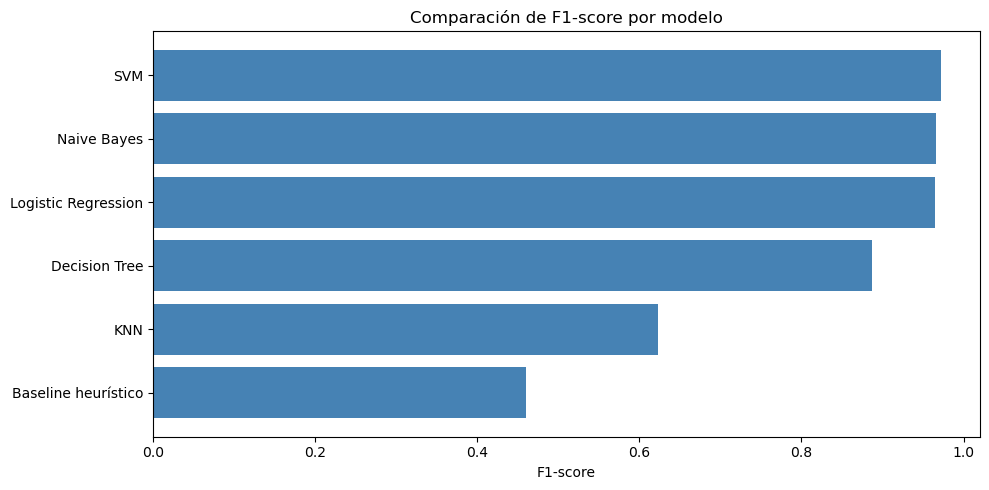

In [6]:
plt.figure(figsize=(10, 5))
plt.barh(results['Modelo'], results['F1-score'], color='steelblue')
plt.xlabel('F1-score')
plt.title('Comparación de F1-score por modelo')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()